# HBV Constant Su_max Calibration (Cal/Val)

This notebook runs the constant-Su_max HBV model from hbv_bmi_constant.py with a multi-objective Monte Carlo calibration and calibration/validation split.

In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from hbv_bmi_constant import HBV_Bmi

In [20]:
base = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project')
temp_path = base / 'ERA5_Temp_1980_2026.csv'
precip_path = base / 'Moselle_ERA5_monthly_precip_1980-01-01_2026-02-28.csv'
evap_path = base / 'Moselle_ERA5_monthly_evap_1980-01-01_2026-02-28.csv'
grdc_path = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')
shape_area = 28191724718  # m2

In [ ]:
# # Build monthly dataframe (1980-2020)
# df_t = pd.read_csv(temp_path)
# df_t['year'] = df_t['system:index'].astype(str).str[:4].astype(int)
# df_t['month'] = df_t['system:index'].astype(str).str[4:6].astype(int)
# df_t['temperature_C'] = df_t['temperature_2m'] - 273.15
# temp_monthly = df_t.pivot_table(index='year', columns='month', values='temperature_C').loc[1980:2020]
# temp_array = temp_monthly.values.flatten()

# df_p = pd.read_csv(precip_path)
# df_e = pd.read_csv(evap_path)
# df_p = df_p[(df_p['system:index'] >= 198001) & (df_p['system:index'] <= 202012)].reset_index(drop=True)
# df_e = df_e[(df_e['system:index'] >= 198001) & (df_e['system:index'] <= 202012)].reset_index(drop=True)

# grdc = pd.read_csv(
#     grdc_path,
#     encoding='latin-1',
#     sep=';',
#     skiprows=36,
#     index_col=0,
#     parse_dates=True,
#     usecols=[0, 2],
# )
# grdc.columns = ['q_m3s']
# grdc['year'] = grdc.index.year
# grdc['month'] = grdc.index.month
# q_month = grdc.groupby(['year', 'month'])['q_m3s'].mean().reset_index()
# q_month['Date'] = pd.to_datetime(q_month[['year', 'month']].assign(day=1))
# q_month = q_month[(q_month['year'] >= 1980) & (q_month['year'] <= 2020)].sort_values('Date').reset_index(drop=True)

# dates = pd.date_range('1980-01-01', '2020-12-01', freq='MS')
# monthly_df = pd.DataFrame({
#     'Date': dates,
#     'precip_m_month': df_p['total_precipitation_sum'].values,
#     'evap_m_month': df_e[df_e.columns[1]].values,
#     'temperature_C': temp_array,
#     'q_m3s': q_month['q_m3s'].values,
# })
# monthly_df['days_in_month'] = monthly_df['Date'].dt.days_in_month
# monthly_df['precip_mm_month'] = monthly_df['precip_m_month'] * 1000.0
# monthly_df['pet_mm_month'] = (-monthly_df['evap_m_month']).clip(lower=0) * 1000.0
# monthly_df['precip_mm_day'] = monthly_df['precip_mm_month'] / monthly_df['days_in_month']
# monthly_df['pet_mm_day'] = monthly_df['pet_mm_month'] / monthly_df['days_in_month']
# monthly_df['q_obs_mm_day'] = monthly_df['q_m3s'] * 86400.0 / shape_area * 1000.0
# monthly_df.head()

,Date,precip_m_month,evap_m_month,temperature_C,q_m3s,days_in_month,precip_mm_month,pet_mm_month,precip_mm_day,pet_mm_day,q_obs_mm_day
0,1980-01-01,0.077218,-0.006487,-1.001031,592.322581,31,77.218060,6.487182,2.490905,0.209264,1.815308
1,1980-02-01,0.081914,-0.021555,3.847232,896.241379,29,81.913982,21.554530,2.824620,0.743260,2.746737
2,1980-03-01,0.089754,-0.037676,4.629214,269.935484,31,89.754468,37.676348,2.895305,1.215366,0.827279
3,1980-04-01,0.060644,-0.064560,6.306908,293.433333,30,60.644102,64.560134,2.021470,2.152004,0.899294
4,1980-05-01,0.073371,-0.092885,10.861671,180.354839,31,73.371170,92.885477,2.366812,2.996306,0.552739


In [ ]:
# # Write forcing files for hbv_bmi_constant.py (file-based model interface)
# # Use a writable temp directory and unique filenames to avoid permission/lock conflicts.
# time_index = pd.DatetimeIndex(monthly_df['Date'].values)
# pr = xr.Dataset({'pr': ('time', monthly_df['precip_mm_day'].to_numpy())}, coords={'time': time_index})
# pet = xr.Dataset({'evspsblpot': ('time', monthly_df['pet_mm_day'].to_numpy())}, coords={'time': time_index})

# run_dir = Path.home() / 'tmp_hbv_constant'
# run_dir.mkdir(parents=True, exist_ok=True)
# run_tag = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S_%f')

# pr_path = run_dir / f'tmp_pr_constant_{run_tag}.nc'
# pet_path = run_dir / f'tmp_pet_constant_{run_tag}.nc'
# cfg_path = run_dir / f'tmp_hbv_constant_config_{run_tag}.json'

# pr.to_netcdf(pr_path, mode='w')
# pet.to_netcdf(pet_path, mode='w')

# q_obs = monthly_df['q_obs_mm_day'].to_numpy()
# years = time_index.year

# print('Wrote forcing files:')
# print(pr_path)
# print(pet_path)

Wrote forcing files:
/Users/doriswong/tmp_hbv_constant/tmp_pr_constant_20260402_165427_066866.nc
/Users/doriswong/tmp_hbv_constant/tmp_pet_constant_20260402_165427_066866.nc


### This is what Claude wrote me

In [23]:
def nse(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    den = np.sum((obs - np.mean(obs)) ** 2)
    if den <= 0:
        return np.nan
    return 1 - np.sum((obs - sim) ** 2) / den

def log_nse(obs, sim, eps=1e-6):
    obs = np.maximum(np.asarray(obs, dtype=float), eps)
    sim = np.maximum(np.asarray(sim, dtype=float), eps)
    return nse(np.log(obs), np.log(sim))

def rel_bias(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    s_obs = np.sum(obs)
    if s_obs == 0:
        return np.nan
    return (np.sum(sim) - s_obs) / s_obs

def combined_score(obs, sim, w_nse=0.45, w_lognse=0.35, w_bias=0.20):
    a = nse(obs, sim)
    b = log_nse(obs, sim)
    c = rel_bias(obs, sim)
    if not (np.isfinite(a) and np.isfinite(b) and np.isfinite(c)):
        return np.nan
    return w_nse * a + w_lognse * b - w_bias * abs(c)

## Apples-to-Apples Check Against Exercise 4 Logic

This section mirrors Exercise 4 choices as closely as possible in this workspace:
- Same HBV implementation family (constant `Su_max` model)
- Same parameter bounds from the exercise
- Same objective period (2011 only)
- NSE / logNSE objective focus

It also corrects a key unit mismatch by converting simulated monthly-step output to mm/day using days per month before computing NSE.

In [7]:
# Import hourly data, resample to daily, and clip to Exercise 3 period (2010-2012)
from pathlib import Path
import pandas as pd

base_path = globals().get('base', Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project'))

df_p = pd.read_csv(base_path / 'ERA5_total_precipitation_hourly_2011-01-01_2017-12-31.csv')
df_e = pd.read_csv(base_path / 'ERA5_total_evaporation_hourly_2011-01-01_2017-12-31.csv')

# Parse hourly timestamp format like 20110101T00
for frame in (df_p, df_e):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%dT%H')

p_col = [c for c in df_p.columns if c not in ['system:index', 'time']][0]
e_col = [c for c in df_e.columns if c not in ['system:index', 'time']][0]

# Sum hourly depths to daily totals (ERA5 hourly totals are accumulated depth per hour)
df_p_daily = (
    df_p.set_index('time')[[p_col]]
    .resample('D').sum()
    .rename(columns={p_col: 'precip_m_day'})
)

df_e_daily = (
    df_e.set_index('time')[[e_col]]
    .resample('D').sum()
    .rename(columns={e_col: 'evap_m_day'})
)

# Clip to the Exercise 3 period
start_ex3 = pd.Timestamp('2010-01-01')
end_ex3 = pd.Timestamp('2012-12-31')

df_p_daily = df_p_daily.loc[start_ex3:end_ex3]
df_e_daily = df_e_daily.loc[start_ex3:end_ex3]

# Overwrite df_p and df_e with daily clipped data for downstream use
df_p = df_p_daily.copy()
df_e = df_e_daily.copy()

print('Daily precipitation range:', df_p.index.min(), 'to', df_p.index.max(), '| n =', len(df_p))
print('Daily evaporation range:  ', df_e.index.min(), 'to', df_e.index.max(), '| n =', len(df_e))
pd.concat([df_p.head(3), df_e.head(3)], axis=1)

Daily precipitation range: 2011-01-01 00:00:00 to 2012-12-31 00:00:00 | n = 731
Daily evaporation range:   2011-01-01 00:00:00 to 2012-12-31 00:00:00 | n = 731


,precip_m_day,evap_m_day
time,,
2011-01-01,0.000623,-0.000018
2011-01-02,0.000219,-0.000168
2011-01-03,0.000124,-0.000085


## Daily Monte Carlo (2011-2012)

This section runs a fresh MC calibration for 2011-2012 using daily forcing (`df_p`, `df_e`) and daily observed discharge, while reusing the existing `nse`, `log_nse`, and `rel_bias` functions.

In [21]:
# Build daily forcing and daily observed discharge for 2011-2014 (2011 warmup)
# Self-contained so it can run even if earlier cells were not executed.
from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr

start_mc = pd.Timestamp('2011-01-01')
end_mc = pd.Timestamp('2014-12-31')

base_path = globals().get('base', Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project'))
shape_area_local = float(globals().get('shape_area', 28191724718.0))
grdc_path_local = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')

# Ensure daily forcing exists and covers the requested window; otherwise rebuild from hourly files.
need_rebuild = True
if ('df_p' in globals()) and ('df_e' in globals()):
    try:
        need_rebuild = (df_p.index.min() > start_mc) or (df_p.index.max() < end_mc) or (df_e.index.min() > start_mc) or (df_e.index.max() < end_mc)
    except Exception:
        need_rebuild = True

if need_rebuild:
    df_p_h = pd.read_csv(base_path / 'ERA5_total_precipitation_hourly_2011-01-01_2017-12-31.csv')
    df_e_h = pd.read_csv(base_path / 'ERA5_total_evaporation_hourly_2011-01-01_2017-12-31.csv')

    for frame in (df_p_h, df_e_h):
        frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%dT%H')

    p_col = [c for c in df_p_h.columns if c not in ['system:index', 'time']][0]
    e_col = [c for c in df_e_h.columns if c not in ['system:index', 'time']][0]

    df_p = df_p_h.set_index('time')[[p_col]].resample('D').sum().rename(columns={p_col: 'precip_m_day'})
    df_e = df_e_h.set_index('time')[[e_col]].resample('D').sum().rename(columns={e_col: 'evap_m_day'})

# Convert forcing to mm/day and ensure positive PET sign
daily_forcing = pd.concat([df_p, df_e], axis=1).loc[start_mc:end_mc].copy()
daily_forcing['pr_mm_day'] = daily_forcing['precip_m_day'] * 1000.0
daily_forcing['pet_mm_day'] = (-daily_forcing['evap_m_day']).clip(lower=0) * 1000.0

# Daily observed Q in mm/day
if 'grdc' not in globals():
    grdc = pd.read_csv(
        grdc_path_local,
        encoding='latin-1',
        sep=';',
        skiprows=36,
        index_col=0,
        parse_dates=True,
        usecols=[0, 2],
    )
    grdc.columns = ['q_m3s']

q_obs_daily = (
    grdc['q_m3s']
    .loc[start_mc:end_mc]
    .reindex(daily_forcing.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

# Calibration score period excludes warmup year
cal_mask = (daily_forcing.index >= pd.Timestamp('2012-01-01')) & (daily_forcing.index <= pd.Timestamp('2014-12-31'))

# Write daily forcing to temporary NetCDF files
run_dir = Path.home() / 'tmp_hbv_constant'
run_dir.mkdir(parents=True, exist_ok=True)
run_tag_daily = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S_%f')

pr_daily_ds = xr.Dataset({'pr': ('time', daily_forcing['pr_mm_day'].to_numpy(dtype=float))}, coords={'time': daily_forcing.index})
pet_daily_ds = xr.Dataset({'evspsblpot': ('time', daily_forcing['pet_mm_day'].to_numpy(dtype=float))}, coords={'time': daily_forcing.index})

pr_daily_path = run_dir / f'tmp_pr_daily_{run_tag_daily}.nc'
pet_daily_path = run_dir / f'tmp_pet_daily_{run_tag_daily}.nc'
cfg_daily_path = run_dir / f'tmp_hbv_daily_config_{run_tag_daily}.json'

pr_daily_ds.to_netcdf(pr_daily_path, mode='w')
pet_daily_ds.to_netcdf(pet_daily_path, mode='w')

print('MC forcing period:', daily_forcing.index.min(), 'to', daily_forcing.index.max(), '| n =', len(daily_forcing))
print('Calibration score period (after warmup): 2012-01-01 to 2014-12-31')
print('Daily files written:')
print(pr_daily_path)
print(pet_daily_path)

MC forcing period: 2011-01-01 00:00:00 to 2014-12-31 00:00:00 | n = 1461
Calibration score period (after warmup): 2012-01-01 to 2014-12-31
Daily files written:
/Users/doriswong/tmp_hbv_constant/tmp_pr_daily_20260404_132250_630864.nc
/Users/doriswong/tmp_hbv_constant/tmp_pet_daily_20260404_132250_630864.nc


In [22]:
# MC simulation for 2011-2014 with 2011 warmup (score on 2012-2014)
# Define metrics locally if previous function cell has not been run.
if 'nse' not in globals():
    def nse(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        den = np.sum((obs - np.mean(obs)) ** 2)
        if den <= 0:
            return np.nan
        return 1 - np.sum((obs - sim) ** 2) / den

if 'log_nse' not in globals():
    def log_nse(obs, sim, eps=1e-6):
        obs = np.maximum(np.asarray(obs, dtype=float), eps)
        sim = np.maximum(np.asarray(sim, dtype=float), eps)
        return nse(np.log(obs), np.log(sim))

if 'rel_bias' not in globals():
    def rel_bias(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        s_obs = np.sum(obs)
        if s_obs == 0:
            return np.nan
        return (np.sum(sim) - s_obs) / s_obs

ParMinn_mc = np.array([0.0, 0.2, 40.0, 0.5, 0.001, 0.0, 0.01, 0.0001])
ParMaxn_mc = np.array([8.0, 1.0, 800.0, 4.0, 0.3, 10.0, 0.1, 0.01])

N_mc = 1000
results_mc = []

obs_cal = q_obs_daily[cal_mask]

for _ in range(N_mc):
    p = np.random.uniform(ParMinn_mc, ParMaxn_mc)
    cfg = {
        'precipitation_file': str(pr_daily_path),
        'potential_evaporation_file': str(pet_daily_path),
        'parameters': ','.join([f'{v:.10f}' for v in p]),
        'initial_storage': '0.0,100.0,0.0,5.0',
    }
    with open(cfg_daily_path, 'w') as f:
        json.dump(cfg, f)

    m = HBV_Bmi()
    m.initialize(str(cfg_daily_path))

    sim = []
    while m.current_timestep < m.end_timestep:
        m.update()
        out = np.array([0.0])
        m.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    sim_cal = sim[cal_mask]
    nse_cal = nse(obs_cal, sim_cal)
    lognse_cal = log_nse(obs_cal, sim_cal)
    rb_cal = rel_bias(obs_cal, sim_cal)

    if np.isfinite(nse_cal) and np.isfinite(lognse_cal):
        results_mc.append({
            'params': p,
            'sim_mm_day': sim,
            'nse_cal': nse_cal,
            'lognse_cal': lognse_cal,
            'rb_cal': rb_cal,
        })

if not results_mc:
    raise RuntimeError('No valid daily MC runs found for 2011-2014.')

best_daily = max(results_mc, key=lambda d: d['nse_cal'])
sim_daily_best = best_daily['sim_mm_day']

summary_daily = pd.DataFrame({
    'metric': ['NSE_cal_2012_2014', 'logNSE_cal_2012_2014', 'rel_bias_cal_2012_2014'],
    'value': [best_daily['nse_cal'], best_daily['lognse_cal'], best_daily['rb_cal']],
})

print('Valid runs:', len(results_mc), '/', N_mc)
summary_daily

Valid runs: 1000 / 1000


,metric,value
0,NSE_cal_2012_2014,0.766061
1,logNSE_cal_2012_2014,0.754783
2,rel_bias_cal_2012_2014,0.049105


In [25]:
print(best_daily)

{'params': array([2.66513528e+00, 3.19149142e-01, 2.63783935e+02, 1.26387331e+00,
       7.57982473e-02, 3.47496049e+00, 9.91091167e-02, 1.10481901e-03]), 'sim_mm_day': array([1.23463003e-03, 4.32687834e-03, 5.58134923e-03, ...,
       1.87508841e+00, 1.75750036e+00, 1.62888979e+00], shape=(1461,)), 'nse_cal': np.float64(0.7660613013378837), 'lognse_cal': np.float64(0.7547827464589246), 'rb_cal': np.float64(0.04910508844010792)}


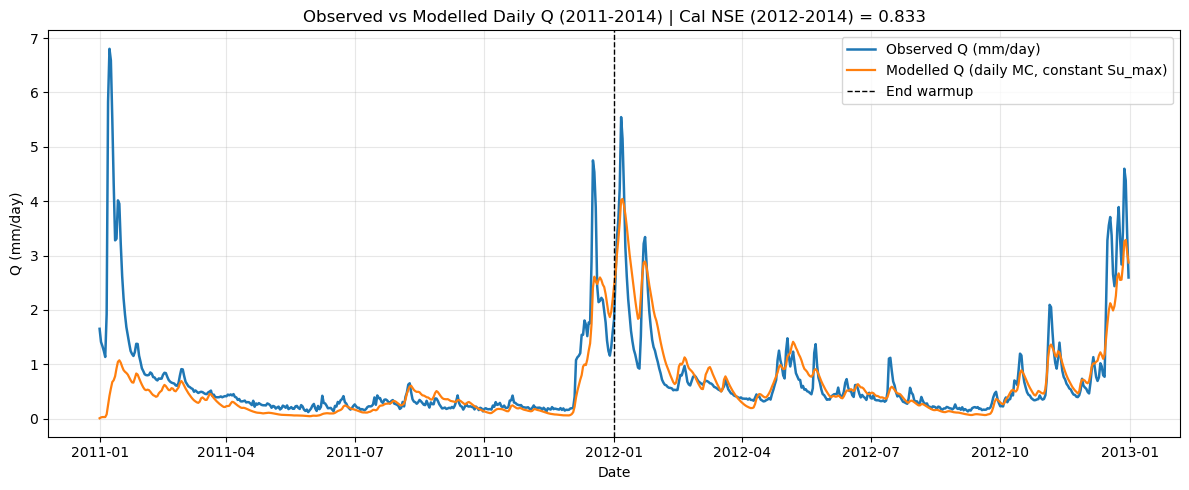

,metric,value
0,NSE_cal_2012_2014,0.833137
1,logNSE_cal_2012_2014,0.778813
2,rel_bias_cal_2012_2014,0.035360


In [20]:
# Plot best daily MC hydrograph for 2011-2014 (2011 warmup + 2012-2014 calibration score)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_forcing.index, q_obs_daily, label='Observed Q (mm/day)', lw=1.8)
ax.plot(daily_forcing.index, sim_daily_best, label='Modelled Q (daily MC, constant Su_max)', lw=1.6)
ax.axvline(pd.Timestamp('2012-01-01'), color='k', ls='--', lw=1, label='End warmup')
ax.set_title(f'Observed vs Modelled Daily Q (2011-2014) | Cal NSE (2012-2014) = {best_daily["nse_cal"]:.3f}')
ax.set_xlabel('Date')
ax.set_ylabel('Q (mm/day)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

summary_daily

## Validation Period (2013-2014)

This section runs the calibrated best parameter set from 2011-2012 on a separate validation period (2013-2014) without recalibration.

In [23]:
# Build validation forcing/obs for 2015-2016 and run model with calibrated best_daily parameters
val_start = pd.Timestamp('2015-01-01')
val_end = pd.Timestamp('2016-12-31')

# Recreate daily forcing from hourly source for validation window
base_path = globals().get('base_path', Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project'))
df_p_h = pd.read_csv(base_path / 'ERA5_total_precipitation_hourly_2011-01-01_2017-12-31.csv')
df_e_h = pd.read_csv(base_path / 'ERA5_total_evaporation_hourly_2011-01-01_2017-12-31.csv')

for frame in (df_p_h, df_e_h):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%dT%H')

p_col_h = [c for c in df_p_h.columns if c not in ['system:index', 'time']][0]
e_col_h = [c for c in df_e_h.columns if c not in ['system:index', 'time']][0]

df_p_val = df_p_h.set_index('time')[[p_col_h]].resample('D').sum().rename(columns={p_col_h: 'precip_m_day'})
df_e_val = df_e_h.set_index('time')[[e_col_h]].resample('D').sum().rename(columns={e_col_h: 'evap_m_day'})

val_forcing = pd.concat([df_p_val, df_e_val], axis=1).loc[val_start:val_end].copy()
val_forcing['pr_mm_day'] = val_forcing['precip_m_day'] * 1000.0
val_forcing['pet_mm_day'] = (-val_forcing['evap_m_day']).clip(lower=0) * 1000.0

if 'grdc' not in globals():
    grdc = pd.read_csv(
        Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt'),
        encoding='latin-1',
        sep=';',
        skiprows=36,
        index_col=0,
        parse_dates=True,
        usecols=[0, 2],
    )
    grdc.columns = ['q_m3s']

shape_area_local = float(globals().get('shape_area_local', globals().get('shape_area', 28191724718.0)))
q_obs_val = (
    grdc['q_m3s']
    .loc[val_start:val_end]
    .reindex(val_forcing.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

# Write validation forcing to temp files
run_dir = Path.home() / 'tmp_hbv_constant'
run_dir.mkdir(parents=True, exist_ok=True)
val_tag = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S_%f')

pr_val_ds = xr.Dataset({'pr': ('time', val_forcing['pr_mm_day'].to_numpy(dtype=float))}, coords={'time': val_forcing.index})
pet_val_ds = xr.Dataset({'evspsblpot': ('time', val_forcing['pet_mm_day'].to_numpy(dtype=float))}, coords={'time': val_forcing.index})

pr_val_path = run_dir / f'tmp_pr_val_{val_tag}.nc'
pet_val_path = run_dir / f'tmp_pet_val_{val_tag}.nc'
cfg_val_path = run_dir / f'tmp_hbv_val_config_{val_tag}.json'

pr_val_ds.to_netcdf(pr_val_path, mode='w')
pet_val_ds.to_netcdf(pet_val_path, mode='w')

cfg_val = {
    'precipitation_file': str(pr_val_path),
    'potential_evaporation_file': str(pet_val_path),
    'parameters': ','.join([f'{v:.10f}' for v in best_daily['params']]),
    'initial_storage': '0.0,100.0,0.0,5.0',
}
with open(cfg_val_path, 'w') as f:
    json.dump(cfg_val, f)

m_val = HBV_Bmi()
m_val.initialize(str(cfg_val_path))

sim_val = []
while m_val.current_timestep < m_val.end_timestep:
    m_val.update()
    out = np.array([0.0])
    m_val.get_value('Q', out)
    sim_val.append(out[0])

sim_val = np.asarray(sim_val, dtype=float)

val_metrics = pd.DataFrame({
    'metric': ['NSE_val_2015_2016', 'logNSE_val_2015_2016', 'rel_bias_val_2015_2016'],
    'value': [nse(q_obs_val, sim_val), log_nse(q_obs_val, sim_val), rel_bias(q_obs_val, sim_val)],
})

print('Validation period:', val_forcing.index.min(), 'to', val_forcing.index.max(), '| n =', len(val_forcing))
val_metrics

Validation period: 2015-01-01 00:00:00 to 2016-12-31 00:00:00 | n = 731


,metric,value
0,NSE_val_2015_2016,0.729299
1,logNSE_val_2015_2016,0.641122
2,rel_bias_val_2015_2016,-0.088849


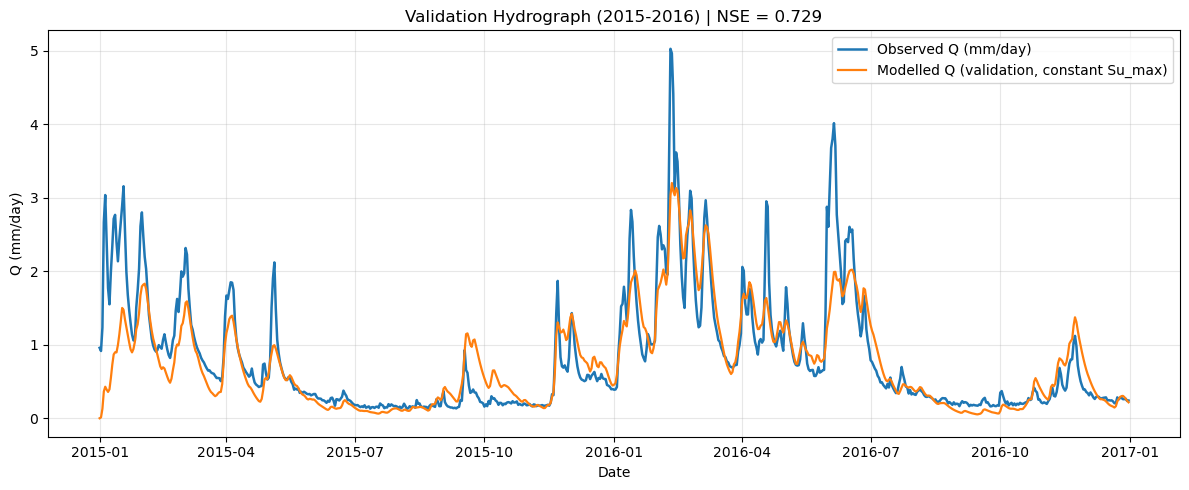

,metric,value
0,NSE_val_2015_2016,0.729299
1,logNSE_val_2015_2016,0.641122
2,rel_bias_val_2015_2016,-0.088849


In [24]:
# Plot validation hydrograph (2015-2016)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(val_forcing.index, q_obs_val, label='Observed Q (mm/day)', lw=1.8)
ax.plot(val_forcing.index, sim_val, label='Modelled Q (validation, constant Su_max)', lw=1.6)
ax.set_title(f'Validation Hydrograph (2015-2016) | NSE = {nse(q_obs_val, sim_val):.3f}')
ax.set_xlabel('Date')
ax.set_ylabel('Q (mm/day)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

val_metrics